In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 300

df = pd.DataFrame({
    "ad_id": range(1, n+1),
    "campaign": np.random.choice(["A", "B", "C", "D"], n),
    "audience": np.random.choice(["Gen Z", "Millennials", "Broad", "Interest"], n),
    "spend": np.random.randint(50, 500, n),
    "impressions": np.random.randint(1000, 50000, n),
})

df["clicks"] = (df["impressions"] * np.random.uniform(0.01, 0.08, n)).astype(int)
df["conversions"] = (df["clicks"] * np.random.uniform(0.02, 0.15, n)).astype(int)

df["revenue"] = df["conversions"] * np.random.randint(10, 50, n)

df.head()

,ad_id,campaign,audience,spend,impressions,clicks,conversions,revenue
0,1,C,Gen Z,414,23700,1866,100,3300
1,2,D,Gen Z,421,35620,635,61,1586
2,3,A,Broad,399,38678,1463,39,819
3,4,C,Millennials,96,21559,1678,141,5781
4,5,C,Millennials,404,28509,2012,196,4704


In [2]:
df["CTR"] = df["clicks"] / df["impressions"]
df["CPC"] = df["spend"] / df["clicks"]
df["CPA"] = df["spend"] / (df["conversions"] + 1)
df["ROAS"] = df["revenue"] / df["spend"]

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

df.head()

,ad_id,campaign,audience,spend,impressions,clicks,conversions,revenue,CTR,CPC,CPA,ROAS
0,1,C,Gen Z,414,23700,1866,100,3300,0.078734,0.221865,4.099010,7.971014
1,2,D,Gen Z,421,35620,635,61,1586,0.017827,0.662992,6.790323,3.767221
2,3,A,Broad,399,38678,1463,39,819,0.037825,0.272727,9.975000,2.052632
3,4,C,Millennials,96,21559,1678,141,5781,0.077833,0.057211,0.676056,60.218750
4,5,C,Millennials,404,28509,2012,196,4704,0.070574,0.200795,2.050761,11.643564


In [3]:
def optimize_budget(df, total_budget=10000):

    # score ads by ROAS + CTR balance
    df["score"] = (df["ROAS"] * 0.7) + (df["CTR"] * 100 * 0.3)

    df = df.sort_values("score", ascending=False)

    df["allocated_budget"] = (df["score"] / df["score"].sum()) * total_budget

    return df

optimized_df = optimize_budget(df)
optimized_df.head()

,ad_id,campaign,audience,spend,impressions,clicks,conversions,revenue,CTR,CPC,CPA,ROAS,score,allocated_budget
245,246,B,Interest,54,47271,3346,480,20640,0.070783,0.016139,0.112266,382.222222,269.679056,740.876350
176,177,C,Gen Z,111,46415,2900,373,16412,0.062480,0.038276,0.296791,147.855856,105.373493,289.487549
201,202,D,Gen Z,118,47892,2879,349,16403,0.060114,0.040986,0.337143,139.008475,99.109365,272.278410
123,124,C,Broad,144,43808,2574,312,14976,0.058756,0.055944,0.460064,104.000000,74.562692,204.842511
99,100,A,Gen Z,209,49212,3238,480,20640,0.065797,0.064546,0.434511,98.755981,71.103095,195.338127


In [4]:
top_ads = optimized_df.sort_values("score", ascending=False).head(10)
top_ads[["ad_id", "campaign", "audience", "ROAS", "CTR", "allocated_budget"]]

,ad_id,campaign,audience,ROAS,CTR,allocated_budget
245,246,B,Interest,382.222222,0.070783,740.876350
176,177,C,Gen Z,147.855856,0.062480,289.487549
201,202,D,Gen Z,139.008475,0.060114,272.278410
123,124,C,Broad,104.000000,0.058756,204.842511
99,100,A,Gen Z,98.755981,0.065797,195.338127
11,12,C,Broad,70.242775,0.050009,139.203829
37,38,A,Broad,69.394286,0.043005,136.994886
52,53,C,Gen Z,68.040000,0.065646,136.256472
168,169,C,Gen Z,67.516129,0.077259,136.206149
3,4,C,Millennials,60.218750,0.077833,122.220061


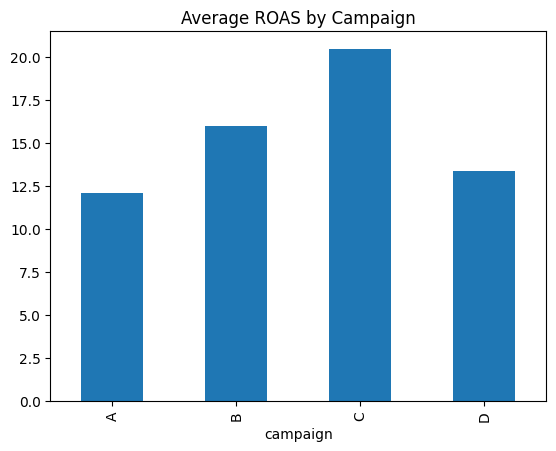

In [5]:
import matplotlib.pyplot as plt

top_campaigns = optimized_df.groupby("campaign")["ROAS"].mean()

top_campaigns.plot(kind="bar")
plt.title("Average ROAS by Campaign")
plt.show()

In [6]:
df.to_csv("synthetic_ads.csv", index=False)